In [1]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.3 MB/s eta 0:00:00


Trial 5 Complete [00h 15m 28s]
val_accuracy: 0.9803109765052795

Best val_accuracy So Far: 0.9999273419380188
Total elapsed time: 01h 20m 42s
Epoch 1/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.6455 - loss: 2.9149 - val_accuracy: 0.8297 - val_loss: 2.0700 - learning_rate: 1.0000e-05
Epoch 2/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8191 - loss: 1.8969 - val_accuracy: 0.8627 - val_loss: 1.4645 - learning_rate: 1.0000e-05
Epoch 3/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8642 - loss: 1.3788 - val_accuracy: 0.9029 - val_loss: 1.1136 - learning_rate: 1.0000e-05
Epoch 4/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8869 - loss: 1.0661 - val_accuracy: 0.8888 - val_loss: 0.9004 - learning_rate: 1.0000e-05
Epoch 5/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.8965 - loss: 0.8589 - val_accuracy: 0.9107 - val_loss: 0.7303 - learning_rate: 1.0000e-05
Epoch 6/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accura

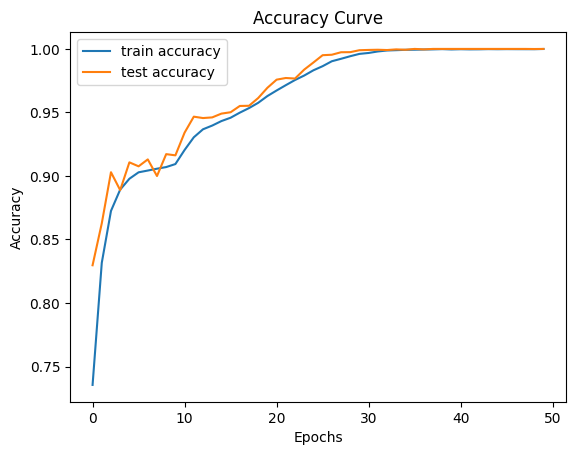

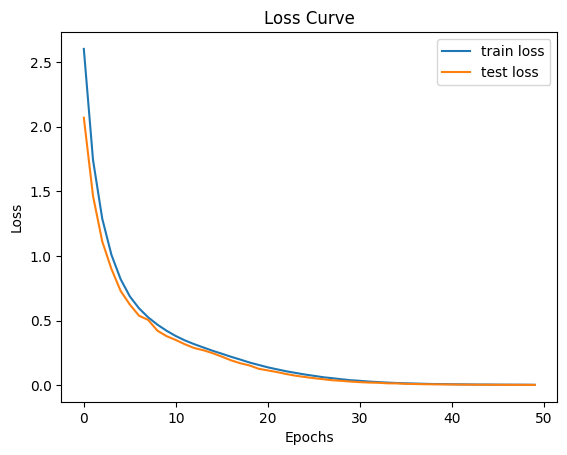

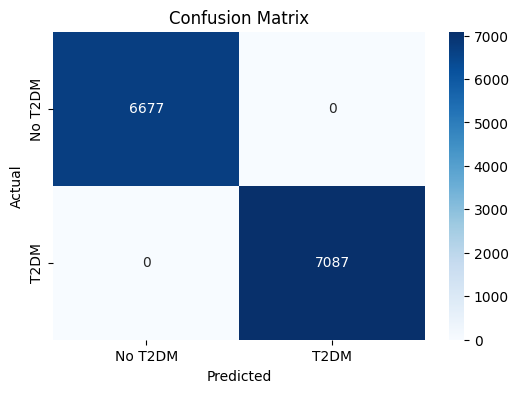

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
import keras_tuner as kt

# Load the dataset
df = pd.read_csv('/content/merged_CGM_clinical_data.csv')

# Preprocess the data
df['Hora'] = pd.to_timedelta(df['Hora']).dt.total_seconds()  # Convert 'Hora' to seconds
df = df.dropna()

# Label encode the target column (T2DM)
le = LabelEncoder()
df['T2DM'] = le.fit_transform(df['T2DM'])  # Assuming it's categorical (like 'Yes'/'No')

# Define numerical columns
numerical_cols = ['Hora', 'Glucemia', 'BMI', 'age', 'HbA1c', 'follow.up']

# Scale the numerical columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Handle class imbalance by oversampling the minority class
df_majority = df[df.T2DM == 0]  # No T2DM class
df_minority = df[df.T2DM == 1]  # T2DM class

# Upsample minority class
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # sample with replacement
                                 n_samples=len(df_majority),    # to match majority class
                                 random_state=42)  # reproducible results

# Combine majority and upsampled minority class
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Function to create sequences per patient
def create_sequences_per_patient(df, window_size, numerical_cols, target_col):
    sequences = []
    labels = []

    grouped_df = df.groupby('Patient_ID')  # Group by Patient_ID
    for _, group in grouped_df:
        group = group.sort_values('Hora')  # Sort by time if necessary
        X_data = group[numerical_cols].values
        y_data = group[target_col].astype(int).values

        for i in range(len(group) - window_size):
            sequences.append(X_data[i:i + window_size])
            labels.append(y_data[i + window_size])  # Target is the value after the window

    return np.array(sequences), np.array(labels)

# Define target column
target_col = 'T2DM'

# Set the number of timesteps
window_size = 10

# Call the function to create sequences for each patient
X, y = create_sequences_per_patient(df_upsampled, window_size, numerical_cols, target_col)

# Apply collaborative filtering (via TruncatedSVD) for feature selection
n_components = 5  # Reduce features to 5 dimensions
svd = TruncatedSVD(n_components=n_components)
X_reduced = svd.fit_transform(X.reshape(-1, X.shape[2]))  # Flatten for SVD, then reshape

# Print the explained variance to see how much information is retained
print(f'Explained Variance by Components: {svd.explained_variance_ratio_}')
print(f'Total Explained Variance: {sum(svd.explained_variance_ratio_):.2f}')

# Print which features were chosen after feature selection
original_features = numerical_cols * window_size  # Assuming window size indicates the number of timesteps
chosen_features = svd.components_.argsort(axis=1)[:, ::-1]  # Get indices of components sorted in descending order

print("\nChosen features after feature selection:")
for i, component in enumerate(chosen_features):
    feature_names = [original_features[j] for j in component]
    print(f"Component {i + 1}: {feature_names}")

# Reshape X back to sequences after feature reduction
X_reduced = X_reduced.reshape(X.shape[0], X.shape[1], n_components)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Define the model-building function for Keras Tuner
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))  # Define input shape with multiple timesteps
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=256, step=32), return_sequences=True))  # Units in LSTM layer
    model.add(Dropout(rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))  # Dropout rate
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=256, step=32)))  # Units in LSTM layer
    model.add(Dropout(rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))  # Dropout rate
    model.add(Dense(units=hp.Int('units', min_value=32, max_value=256, step=32), activation='relu', kernel_regularizer=l2(0.01)))  # Dense layer units
    model.add(Dense(units=1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Set up the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,  # Number of hyperparameter combinations to try
    directory='my_dir',  # Directory to store results
    project_name='lstm_hyperparameter_opt'  # Name for this tuning project
)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Initialize ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# Perform hyperparameter search
tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), callbacks=[early_stopping, reduce_lr])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the best hyperparameters
model = tuner.hypermodel.build(best_hps)

# Train the model with the best hyperparameters
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), callbacks=[early_stopping, reduce_lr])

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Plot the accuracy and loss curves
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No T2DM', 'T2DM'], yticklabels=['No T2DM', 'T2DM'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
model.save('my_model.h5')

In [20]:
import joblib
joblib.dump(svd, 'svd_model.joblib')

['svd_model.joblib']

In [21]:
import pickle
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)